# Data Mining - Project 3


## Problem 1 - Data Set familiarization

In [ ]:
!pip install ucimlrepo
!pip install scikit-learn
!pip install matplotlib
!pip install numpy
!pip install pandas

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [15]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition = fetch_ucirepo(id=544) 
  
# data (as pandas dataframes) 
X = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.features 
y = estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.data.targets.squeeze() 
  
# metadata 
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.metadata) 
  
# variable information 
print(estimation_of_obesity_levels_based_on_eating_habits_and_physical_condition.variables) 


{'uci_id': 544, 'name': 'Estimation of Obesity Levels Based On Eating Habits and Physical Condition ', 'repository_url': 'https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition', 'data_url': 'https://archive.ics.uci.edu/static/public/544/data.csv', 'abstract': 'This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. ', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 2111, 'num_features': 16, 'feature_types': ['Integer'], 'demographics': ['Gender', 'Age'], 'target_col': ['NObeyesdad'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Tue Sep 10 2024', 'dataset_doi': '10.24432/C5H31Z', 'creators': [], 'intro_paper': {'ID': 358, 'type': 

### 1.1 Why are you interested in this dataset?
I am interested in this dataset because I am personally curious about how obesity levels are correlated or not correlated to a persons eating a physical conditions. 

### 1.2 How many numerical attributes and categorical attributes are there in the dataset?
There are 8 numerical attributes and 9| categorical attributes. 

### 1.3 Are there any missing values in numerical attributes?
No there are no missing values.

### 1.4.1 Why do you think clusters will be present in this dataset?
I think there will be clusters present because a persons weight should be correlated to their eating habits and their physical conditions. 

### 1.4.2 Why might finding clusters in this dataset be helpful?
Doctors may be able to use this data to show how a persons current eating habits and physical conditions could predict their obesity level. 

### 1.4.3 How many clusters do you expect to see in this dataset?
I think there is going to be around 2 to 5 clusters. Mainly becuase a society may be more prone to one style of eating habits and physical conditions so it could be a 50/50 or there would be more. 

### 1.4.4 Do you expect to see clusters of similar size? Why or why not?
No, I imagine clusters will vary and create a linear distribution.

## Problem 2 - Clustering Function Implementations

The functions below implement `k`-means, DBSCAN, and clustering precision without calling existing clustering algorithm implementations. The last code cell contains small test cases for correctness.


In [2]:
from collections import deque

def k_means_clustering(data, k, epsilon, max_iter=300, random_state=42, initial_centroids=None):
    """Run k-means clustering using Euclidean distance.

    Returns a dictionary with cluster centroids, point labels, cluster membership,
    and the final objective value (sum of squared distances).
    """
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError("data must be a 2D numeric matrix")
    n_samples, n_features = data.shape
    if not 1 <= k <= n_samples:
        raise ValueError("k must be between 1 and the number of samples")
    if epsilon < 0:
        raise ValueError("epsilon must be non-negative")

    if initial_centroids is not None:
        centroids = np.asarray(initial_centroids, dtype=float).copy()
        if centroids.shape != (k, n_features):
            raise ValueError("initial_centroids must have shape (k, n_features)")
    else:
        rng = np.random.default_rng(random_state)
        initial_indices = rng.choice(n_samples, size=k, replace=False)
        centroids = data[initial_indices].copy()

    for _ in range(max_iter):
        distances = np.sum((data[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
        labels = np.argmin(distances, axis=1)
        new_centroids = centroids.copy()

        for cluster_index in range(k):
            cluster_points = data[labels == cluster_index]
            if len(cluster_points) > 0:
                new_centroids[cluster_index] = cluster_points.mean(axis=0)

        centroid_shift = np.max(np.linalg.norm(new_centroids - centroids, axis=1))
        centroids = new_centroids
        if centroid_shift <= epsilon:
            break

    final_distances = np.sum((data[:, None, :] - centroids[None, :, :]) ** 2, axis=2)
    final_labels = np.argmin(final_distances, axis=1)
    clusters = [np.where(final_labels == cluster_index)[0].tolist() for cluster_index in range(k)]
    objective_value = float(final_distances[np.arange(n_samples), final_labels].sum())

    return {
        "centroids": centroids,
        "labels": final_labels,
        "clusters": clusters,
        "objective_value": objective_value,
    }


In [3]:
def dbscan_clustering(data, minpts, epsilon):
    """Run DBSCAN and label each point as core, border, or noise."""
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError("data must be a 2D numeric matrix")
    if minpts < 1:
        raise ValueError("minpts must be at least 1")
    if epsilon < 0:
        raise ValueError("epsilon must be non-negative")

    n_samples = data.shape[0]
    distance_matrix = np.linalg.norm(data[:, None, :] - data[None, :, :], axis=2)
    neighborhoods = [np.where(distance_matrix[i] <= epsilon)[0].tolist() for i in range(n_samples)]
    is_core = np.array([len(neighbors) >= minpts for neighbors in neighborhoods], dtype=bool)

    UNASSIGNED = -99
    NOISE = -1
    labels = np.full(n_samples, UNASSIGNED, dtype=int)
    visited = np.zeros(n_samples, dtype=bool)
    cluster_id = 0

    for point_index in range(n_samples):
        if visited[point_index]:
            continue

        visited[point_index] = True
        if not is_core[point_index]:
            labels[point_index] = NOISE
            continue

        labels[point_index] = cluster_id
        queue = deque(neighborhoods[point_index])
        queued = set(neighborhoods[point_index])

        while queue:
            neighbor_index = queue.popleft()
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                if is_core[neighbor_index]:
                    for expanded_neighbor in neighborhoods[neighbor_index]:
                        if expanded_neighbor not in queued:
                            queue.append(expanded_neighbor)
                            queued.add(expanded_neighbor)

            if labels[neighbor_index] in (UNASSIGNED, NOISE):
                labels[neighbor_index] = cluster_id

        cluster_id += 1

    labels[labels == UNASSIGNED] = NOISE
    point_types = np.full(n_samples, "noise", dtype=object)
    point_types[labels != NOISE] = "border"
    point_types[(labels != NOISE) & is_core] = "core"
    clusters = [np.where(labels == current_cluster)[0].tolist() for current_cluster in range(cluster_id)]

    return {
        "labels": labels,
        "clusters": clusters,
        "point_types": point_types.tolist(),
        "core_mask": is_core,
    }


In [4]:
def clustering_precision(true_labels, predicted_labels):
    """Compute pairwise clustering precision while ignoring predicted noise points."""
    true_labels = np.asarray(true_labels)
    predicted_labels = np.asarray(predicted_labels)

    if true_labels.shape[0] != predicted_labels.shape[0]:
        raise ValueError("true_labels and predicted_labels must have the same length")

    true_positives = 0
    predicted_positive_pairs = 0

    for i in range(len(true_labels) - 1):
        same_predicted_cluster = (predicted_labels[i + 1:] == predicted_labels[i]) & (predicted_labels[i] != -1)
        predicted_positive_pairs += int(np.sum(same_predicted_cluster))
        true_positives += int(np.sum(same_predicted_cluster & (true_labels[i + 1:] == true_labels[i])))

    if predicted_positive_pairs == 0:
        return 0.0
    return true_positives / predicted_positive_pairs


### Problem 2 Test Cases
These tests use small synthetic datasets so the expected clustering behavior is easy to verify.


In [5]:
# k-means: verify clear two-cluster separation and tie-breaking to the lowest-index cluster.
kmeans_tie_data = np.array([[0.0], [2.0], [4.0]])
kmeans_tie_result = k_means_clustering(
    kmeans_tie_data,
    k=2,
    epsilon=1e-9,
    initial_centroids=np.array([[0.0], [4.0]])
)
assert kmeans_tie_result["labels"][1] == 0

kmeans_data = np.array([[0.0, 0.0], [0.0, 1.0], [9.0, 9.0], [9.0, 10.0]])
kmeans_result = k_means_clustering(
    kmeans_data,
    k=2,
    epsilon=1e-9,
    initial_centroids=np.array([[0.0, 0.0], [9.0, 10.0]])
)
kmeans_cluster_sets = {frozenset(cluster) for cluster in kmeans_result["clusters"]}
assert kmeans_cluster_sets == {frozenset({0, 1}), frozenset({2, 3})}

# DBSCAN: verify border/core/noise labeling on a simple 1D dataset.
dbscan_data = np.array([[0.0], [0.1], [0.2], [0.3], [1.0]])
dbscan_result = dbscan_clustering(dbscan_data, minpts=3, epsilon=0.11)
assert len(dbscan_result["clusters"]) == 1
assert set(dbscan_result["clusters"][0]) == {0, 1, 2, 3}
assert dbscan_result["point_types"] == ["border", "core", "core", "border", "noise"]
assert dbscan_result["labels"][-1] == -1

# Clustering precision: perfect clustering should have precision 1.0, and mixed clusters should be lower.
assert abs(clustering_precision([0, 0, 1, 1], [1, 1, 0, 0]) - 1.0) < 1e-12
assert abs(clustering_precision([0, 0, 1, 1], [0, 0, 0, 1]) - (1 / 3)) < 1e-12

print("k-means test clusters:", kmeans_result["clusters"])
print("k-means objective value:", round(kmeans_result["objective_value"], 4))
print("DBSCAN point types:", dbscan_result["point_types"])
print("DBSCAN cluster labels:", dbscan_result["labels"].tolist())
print("All Problem 2 tests passed.")


k-means test clusters: [[0, 1], [2, 3]]
k-means objective value: 1.0
DBSCAN point types: ['border', 'core', 'core', 'border', 'noise']
DBSCAN cluster labels: [0, 0, 0, 0, -1]
All Problem 2 tests passed.


# Part 3 - Analyze your data

### 3.1 Use Sklearns PCA library to linearly transform the dataset into two dimensions. Create a scatter plot of the dataset where x -axis corresponds to 1st principal component and y- axis corresponds to 2nd principal component. Does it look like there are clusters in the dataset in these two dimensions? If so, how many clusters are there?

   Gender   Age  Height  Weight  ...  FAF  TUE        CALC                 MTRANS
0  Female  21.0    1.62    64.0  ...  0.0  1.0          no  Public_Transportation
1  Female  21.0    1.52    56.0  ...  3.0  0.0   Sometimes  Public_Transportation
2    Male  23.0    1.80    77.0  ...  2.0  1.0  Frequently  Public_Transportation
3    Male  27.0    1.80    87.0  ...  2.0  0.0  Frequently                Walking
4    Male  22.0    1.78    89.8  ...  0.0  0.0   Sometimes  Public_Transportation

[5 rows x 16 columns]
0          Normal_Weight
1          Normal_Weight
2          Normal_Weight
3     Overweight_Level_I
4    Overweight_Level_II
Name: NObeyesdad, dtype: str


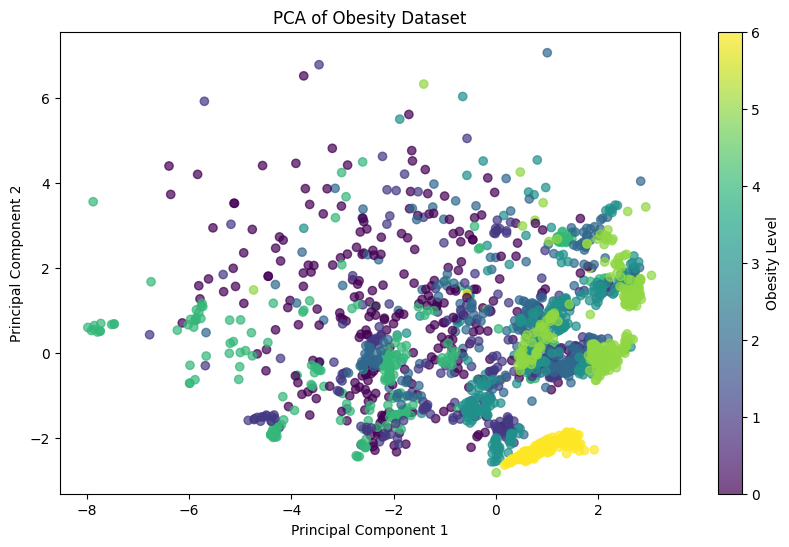

In [ ]:
X = pd.get_dummies(X)  # Convert categorical variables to dummy/indicator variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Standardize features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  # Apply PCA to reduce to 2 dimensions
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(y)[0], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Obesity Dataset')
plt.colorbar(ticks=range(7), label='Obesity Level')
plt.show()
